## Task 2. Mining Association Rules
### a) Exploring the Dataset

---
## 0. Imports and configuration

In [25]:
import json
import os
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
from apyori import apriori

# creating paths
base_path    = r'C:\Users\MiniPC\Documents\Data mining\a1'
data_path    = os.path.join(base_path, 'datas')
sampled_path = os.path.join(base_path, 'sampled_datas')
output_path = os.path.join(base_path, 'product_datas')

PRODUCTS_PATH          = os.path.join(data_path,    'products.csv')
TRANSACTIONS_JSON_PATH = os.path.join(sampled_path, 'transactions_sampled.json')

print('Import done')

Import done


---
## 1. Loading CSV

In [26]:
# map product IDs to names for better readability
products = pd.read_csv(PRODUCTS_PATH)
id_to_name = products.set_index('product_id')['product_name'].to_dict()

# Load sampled transactions and convert IDs to names
with open(TRANSACTIONS_JSON_PATH, 'r') as f:
    transactions_ids = json.load(f)

transactions_name = [
    [id_to_name.get(int(pid), pid) for pid in transaction]
    for transaction in transactions_ids
]

print(f'Transactions loaded: {len(transactions_name):,}')
print(f'Example: {transactions_name[0][:5]}')

Transactions loaded: 146,776
Example: ['Gluten Free Mushroom Risotto Bowl', 'Cold-Brew Black Coffee', 'Kale, Apple, Ginger, Romaine, Spinach, Cucumber, Celery, Parsley, Lemon Cold Pressed Juice Beverage', 'Organic Olive Oil  Spray', 'Baby Swiss Slices Cheese']


---
## 2. Filter products
I keep products that appear in at least 0.1% to keep them meaningful

In [27]:
from collections import Counter

#count items
item_counts = Counter(item for transaction in transactions_name for item in transaction)
n_transactions = len(transactions_name)

# keep items appearing at least 0.1% to reduce noise
MIN_ITEM_SUPPORT = 0.001
min_count = MIN_ITEM_SUPPORT * n_transactions
frequent_items = {item for item, count in item_counts.items() if count >= min_count}

print(f'Total number of transactions:   {n_transactions}')
print(f'Total unique products:    {len(item_counts):,}')
print(f'Products after filtering: {len(frequent_items):,}')
print(f'Removed:                  {len(item_counts) - len(frequent_items):,} rare products')

#filter
transactions_filtered = [
    [item for item in t if item in frequent_items]
    for t in transactions_name
]

# Remove transactions with 1 item (we need at least one antecedent->consequent)
transactions_filtered = [t for t in transactions_filtered if len(t) > 1]
print(f'\nTransactions remaining (size > 1): {len(transactions_filtered):,}')

Total number of transactions:   146776
Total unique products:    38,428
Products after filtering: 1,783
Removed:                  36,645 rare products

Transactions remaining (size > 1): 124,926


---
## 3. Parse Apyori

In [28]:
def parse_apyori_results(results):
    """
    Flattens Apyori output into a structured Pandas DataFrame.
    Calculates support, confidence, and lift for each association.
    """
    rows = []
    for result in results:
        support = result.support
        items = list(result.items)
        for stat in result.ordered_statistics:
            antecedent = list(stat.items_base)
            consequent = list(stat.items_add)
            if not antecedent or not consequent:  
                continue
            rows.append({
                'antecedent': ', '.join(antecedent),
                'consequent': ', '.join(consequent),
                'support':    round(support, 4),
                'confidence': round(stat.confidence, 4),
                'lift':       round(stat.lift, 4),
                'len_ant': len(antecedent),
                'len_con': len(consequent),
                "len_total": len(set(antecedent).union(consequent)),
            })
    df = pd.DataFrame(rows)
    if df.empty:
        return pd.DataFrame(columns=[
            "antecedent","consequent","support","confidence","lift",
            "len_ant","len_con","len_total"
        ])
    return df.sort_values(["lift", "confidence", "support"], ascending=False).reset_index(drop=True)

res = list(apriori(
    transactions_filtered,
    min_support=0.01,
    min_confidence=0.3,
    min_lift=1.0,
    max_length=3
))

rules_df = parse_apyori_results(res)
print("Rules:", len(rules_df))
display(rules_df.head(15))

Rules: 6


,antecedent,consequent,support,confidence,lift,len_ant,len_con,len_total
0,Organic Fuji Apple,Banana,0.0128,0.4028,2.3687,1,1,2
1,Organic Raspberries,Bag of Organic Bananas,0.0152,0.3032,2.2307,1,1,2
2,Honeycrisp Apple,Banana,0.0103,0.3578,2.1041,1,1,2
3,Cucumber Kirby,Banana,0.0119,0.3394,1.9962,1,1,2
4,Strawberries,Banana,0.0161,0.3064,1.8021,1,1,2
5,Organic Avocado,Banana,0.0196,0.3030,1.7819,1,1,2


---
## 4. Experiment 1

In [29]:
# Experiment 1: Relaxed thresholds to get a large range of association
results_1 = list(apriori(
    transactions_filtered,
    min_support=0.005,
    min_confidence=0.1,
    min_lift=1.5,
    max_length=3
))

df1 = parse_apyori_results(results_1)
print(f'Rules generated: {len(df1):,}')
display(df1.head(15))

Rules generated: 106


,antecedent,consequent,support,confidence,lift,len_ant,len_con,len_total
0,Organic Cilantro,Limes,0.0069,0.2680,5.1587,1,1,2
1,Limes,Organic Cilantro,0.0069,0.1322,5.1587,1,1,2
2,Organic Garlic,Organic Yellow Onion,0.0080,0.2069,5.0961,1,1,2
3,Organic Yellow Onion,Organic Garlic,0.0080,0.1962,5.0961,1,1,2
4,Limes,Large Lemon,0.0105,0.2025,3.6498,1,1,2
5,Large Lemon,Limes,0.0105,0.1896,3.6498,1,1,2
6,"Organic Strawberries, Bag of Organic Bananas",Organic Hass Avocado,0.0056,0.2512,3.2614,2,1,3
7,Organic Lemon,Organic Hass Avocado,0.0075,0.2389,3.1011,1,1,2
8,Organic Garlic,Limes,0.0059,0.1520,2.9258,1,1,2
9,Limes,Organic Garlic,0.0059,0.1127,2.9258,1,1,2


---
## 5. Experiment 2

In [30]:
# Experiment 2: More constraints to filter out weaker association
results_2 = list(apriori(
    transactions_filtered,
    min_support=0.01,
    min_confidence=0.2,
    min_lift=1.5,
    max_length=3
))

df2 = parse_apyori_results(results_2)
print(f'Rules generated: {len(df2):,}')
display(df2.head(15))

Rules generated: 12


,antecedent,consequent,support,confidence,lift,len_ant,len_con,len_total
0,Limes,Large Lemon,0.0105,0.2025,3.6498,1,1,2
1,Organic Raspberries,Organic Strawberries,0.0125,0.2500,2.6269,1,1,2
2,Organic Fuji Apple,Banana,0.0128,0.4028,2.3687,1,1,2
3,Organic Raspberries,Bag of Organic Bananas,0.0152,0.3032,2.2307,1,1,2
4,Organic Hass Avocado,Bag of Organic Bananas,0.0225,0.2923,2.1501,1,1,2
5,Honeycrisp Apple,Banana,0.0103,0.3578,2.1041,1,1,2
6,Cucumber Kirby,Banana,0.0119,0.3394,1.9962,1,1,2
7,Strawberries,Banana,0.0161,0.3064,1.8021,1,1,2
8,Organic Avocado,Banana,0.0196,0.3030,1.7819,1,1,2
9,Organic Strawberries,Bag of Organic Bananas,0.0225,0.2361,1.7364,1,1,2


---
## 6. Experiment 3

In [31]:
# Experiment 3: Strict thresholds to identify only the most robust and frequent associations
results_3 = list(apriori(
    transactions_filtered,
    min_support=0.02,
    min_confidence=0.3,
    min_lift=1.5,
    max_length=3
))

df3 = parse_apyori_results(results_3)
print(f'Rules generated: {len(df3):,}')
display(df3.head(15))

Rules generated: 0


,antecedent,consequent,support,confidence,lift,len_ant,len_con,len_total


---
## Comparison : 

,Experiment,min_support,min_confidence,rules_generated
0,Exp 1 (low),0.005,0.1,106
1,Exp 2 (medium),0.010,0.2,12
2,Exp 3 (high),0.020,0.3,0


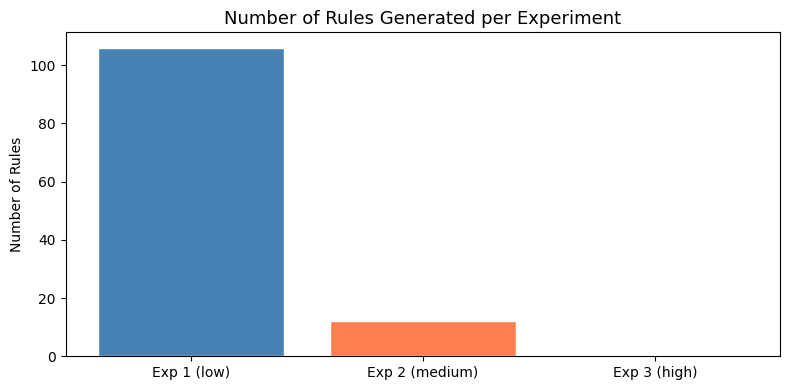

In [32]:
# Comparison: Evaluating the trade-off between threshold intensity and rule count
summary = pd.DataFrame([
    {'Experiment': 'Exp 1 (low)',    'min_support': 0.005, 'min_confidence': 0.10, 'rules_generated': len(df1)},
    {'Experiment': 'Exp 2 (medium)', 'min_support': 0.010, 'min_confidence': 0.20, 'rules_generated': len(df2)},
    {'Experiment': 'Exp 3 (high)',   'min_support': 0.020, 'min_confidence': 0.30, 'rules_generated': len(df3)},
])
display(summary)

# Bar chart to vizualise the difference with differents constraints
fig, ax = plt.subplots(figsize=(8, 4))
ax.bar(summary['Experiment'], summary['rules_generated'], color=['steelblue', 'coral', 'mediumseagreen'], edgecolor='white')
ax.set_title('Number of Rules Generated per Experiment', fontsize=13)
ax.set_ylabel('Number of Rules')
ax.yaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f'{int(x):,}'))
plt.tight_layout()
plt.show()

---
# 8. Save rules


In [35]:
# Sort rules by Lift to prioritize the strongest 'interesting' associations
df1 = df1.sort_values(by="lift", ascending=False)
df2 = df2.sort_values(by="lift", ascending=False)

#save for further uses
df1.to_csv(os.path.join(output_path, 'rules_exp1_low.csv'),    index=False)
df2.to_csv(os.path.join(output_path, 'rules_exp2_medium.csv'), index=False)
df3.to_csv(os.path.join(output_path, 'rules_exp3_high.csv'),   index=False)

print('Rules saved')


Rules saved


In [36]:
# geting infos over high support or confidence

print("Top 3 rules by support (low):")
print(df1.sort_values(by="support", ascending=False).head())

print("\nTop 3 rules by confidence (low):")
print(df1.sort_values(by="confidence", ascending=False).head(3))

Top 3 rules by support (low):
                antecedent              consequent  support  confidence  \
44    Organic Hass Avocado  Bag of Organic Bananas   0.0225      0.2923   
45  Bag of Organic Bananas    Organic Hass Avocado   0.0225      0.1656   
80  Bag of Organic Bananas    Organic Strawberries   0.0225      0.1652   
79    Organic Strawberries  Bag of Organic Bananas   0.0225      0.2361   
74         Organic Avocado                  Banana   0.0196      0.3030   

      lift  len_ant  len_con  len_total  
44  2.1501        1        1          2  
45  2.1501        1        1          2  
80  1.7364        1        1          2  
79  1.7364        1        1          2  
74  1.7819        1        1          2  

Top 3 rules by confidence (low):
                                    antecedent              consequent  \
33                          Organic Fuji Apple                  Banana   
13  Organic Strawberries, Organic Hass Avocado  Bag of Organic Bananas   
46         